In [1]:
import requests 
from bs4 import BeautifulSoup 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
# creating empty list
books_data = [] 

In [3]:
base_url = "http://books.toscrape.com/catalogue/page-{}.html"  
site_url = "http://books.toscrape.com/catalogue/" 

In [4]:
# scraping multiple pages 
for page in range(1,6): 
    url = base_url.format(page) 
    headers = {
        "User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64)" 
                    "AppleWebKit/537.36 (KHTML, like Gecko)" 
                    "Chrome/145.0.0.0 Safari/537.36" 
    }
    response = requests.get(url, headers = headers) 
    soup = BeautifulSoup(response.text, "html.parser") 
    
    books = soup.find_all("article", class_="product_pod") 
    
    for book in books: 
        title = book.h3.a["title"] 

        price_text = book.find("p", class_="price_color").text
        price_text = price_text.replace("Â", "").replace("£", "").strip()
        price = float(price_text) 
        
        rating_text = book.p["class"][1] 
        rating_map = {
            "One":1,
            "Two":2,
            "Three":3,
            "Four":4,
            "Five":5
        } 
        rating = rating_map[rating_text] 
        
        availability = book.find("p", class_="instock availability").get_text(strip=True) 
        
        book_link = book.h3.a["href"] 
        book_url = site_url + book_link 
        
        book_page = requests.get(book_url) 
        book_soup = BeautifulSoup(book_page.text, "html.parser")  
        
        books_data.append({
            "Title": title,
            "Price": price,
            "Rating": rating,
            "Availability": availability 
        })  

In [5]:
df = pd.DataFrame(books_data) 
df.head() 

,Title,Price,Rating,Availability
0,A Light in the Attic,51.77,3,In stock
1,Tipping the Velvet,53.74,1,In stock
2,Soumission,50.10,1,In stock
3,Sharp Objects,47.82,4,In stock
4,Sapiens: A Brief History of Humankind,54.23,5,In stock


In [6]:
df.to_csv("books_dataset.csv", index=False) 

In [7]:
# Understanding Dataset 
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum()) 

Dataset Shape: (100, 4)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Title         100 non-null    object 
 1   Price         100 non-null    float64
 2   Rating        100 non-null    int64  
 3   Availability  100 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ KB
None

Missing Values:
Title           0
Price           0
Rating          0
Availability    0
dtype: int64


In [8]:
print("\nSummary Statistics:")
print(df.describe()) 


Summary Statistics:
            Price      Rating
count  100.000000  100.000000
mean    34.560700    2.930000
std     14.638531    1.423149
min     10.160000    1.000000
25%     19.897500    2.000000
50%     34.775000    3.000000
75%     47.967500    4.000000
max     58.110000    5.000000


In [9]:
# basic analysis

In [17]:
print("Rating Distribution:") 
print(df["Rating"].value_counts()) 

Rating Distribution:
3    22
1    22
5    19
2    19
4    18
Name: Rating, dtype: int64


In [11]:
# visualization 

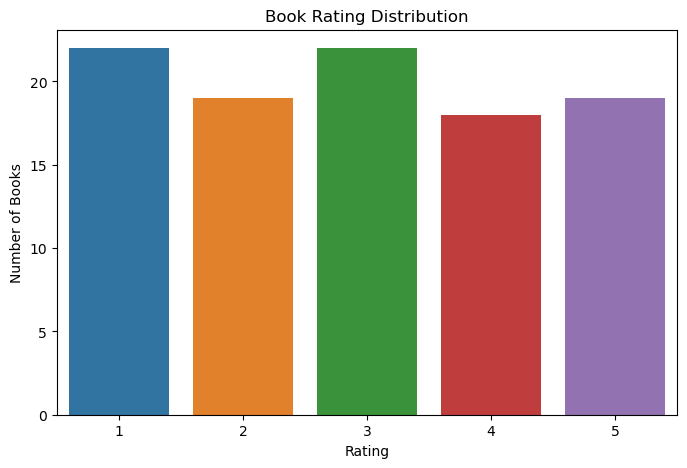

In [12]:
# rating distribution 
plt.figure(figsize=(8,5)) 
sns.countplot(x="Rating", data=df) 
plt.title("Book Rating Distribution") 
plt.xlabel("Rating") 
plt.ylabel("Number of Books") 
plt.savefig("rating_distribution.png", bbox_inches="tight") 
plt.show() 

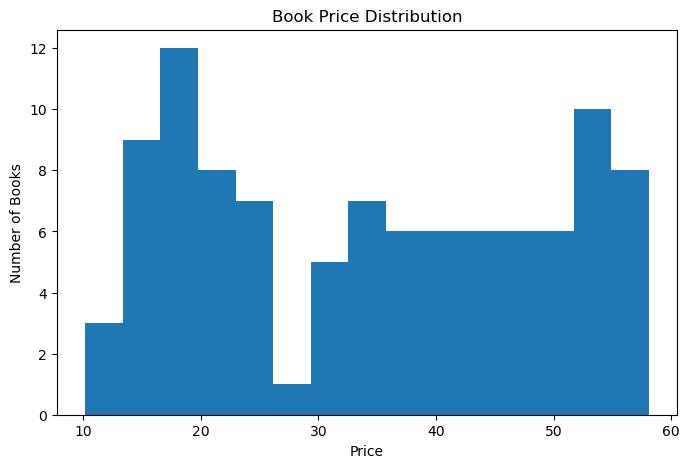

In [13]:
# price distibution 
plt.figure(figsize=(8,5)) 
plt.hist(df["Price"], bins=15) 
plt.title("Book Price Distribution")  
plt.xlabel("Price") 
plt.ylabel("Number of Books") 
plt.savefig("price_distribution.png", bbox_inches="tight") 
plt.show()  

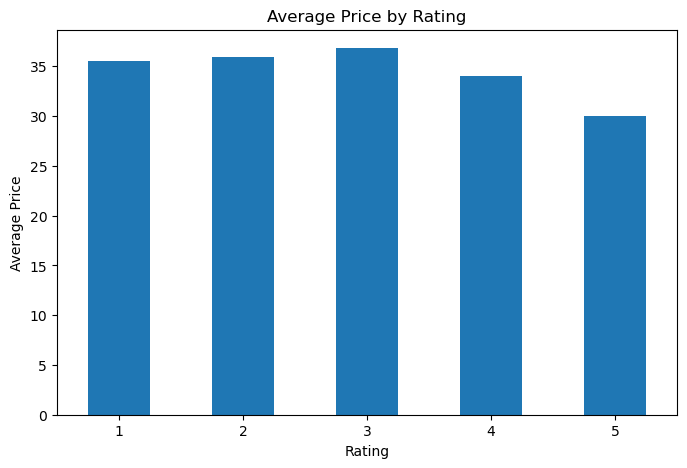

In [14]:
# average price by rating 
avg_price = df.groupby("Rating")["Price"].mean()

plt.figure(figsize=(8,5)) 
avg_price.plot(kind="bar")  
plt.title("Average Price by Rating") 
plt.xlabel("Rating") 
plt.ylabel("Average Price") 
plt.xticks(rotation=0) 
plt.savefig("average_price_by_rating.png", bbox_inches="tight") 
plt.show() 

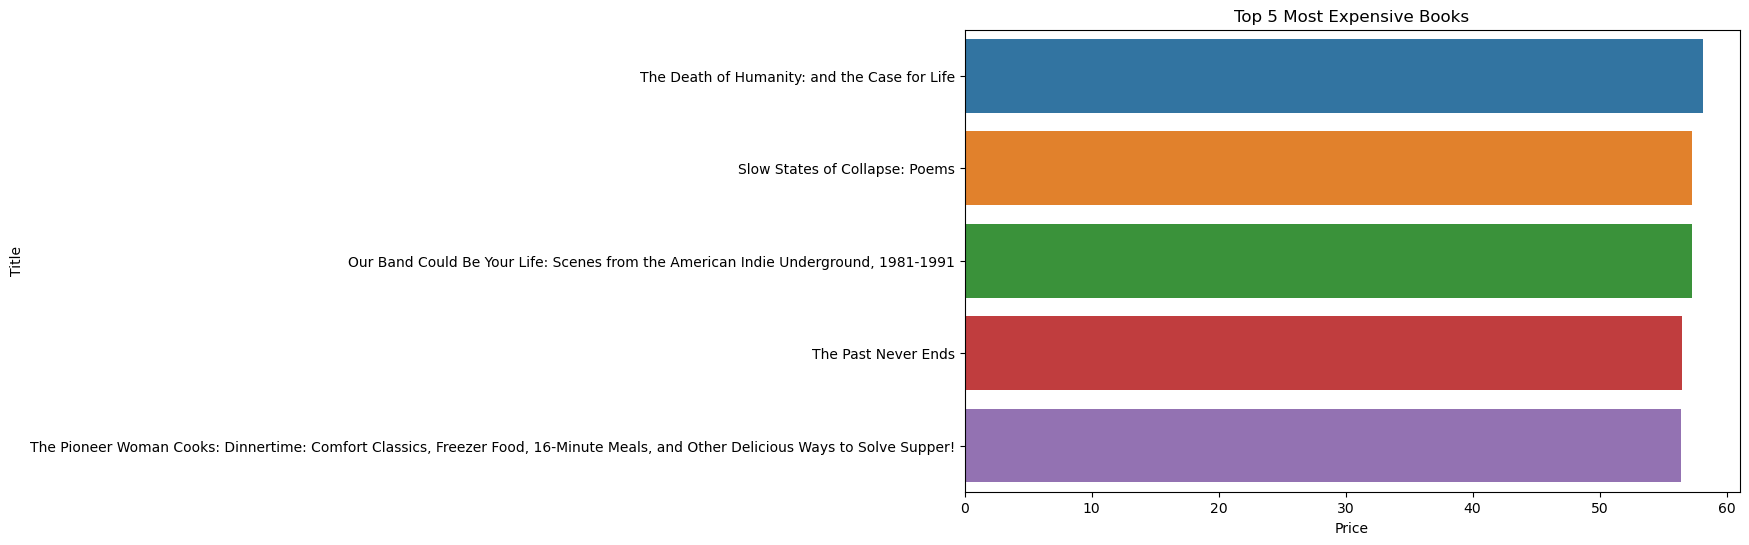

In [15]:
# top 5 expensive books 
top_books = df.sort_values(by="Price", ascending=False).head(5)

plt.figure(figsize=(10,6)) 
sns.barplot(x="Price", y="Title", data=top_books)  
plt.title("Top 5 Most Expensive Books")  
plt.savefig("top_5_expensive_books.png", bbox_inches="tight") 
plt.show() 

In [16]:
print("="*50)
print("KEY FINDINGS")
print("="*50)

print(f"Total Books Scraped: {len(df)}")
print(f"Average Book Price: £{df['Price'].mean():.2f}")
print(f"Highest Book Price: £{df['Price'].max():.2f}")
print(f"Lowest Book Price: £{df['Price'].min():.2f}")

print("\nMost Common Rating:")
print(df['Rating'].mode()[0]) 

KEY FINDINGS
Total Books Scraped: 100
Average Book Price: £34.56
Highest Book Price: £58.11
Lowest Book Price: £10.16

Most Common Rating:
1


In [ ]:
## Conclusion : 
# The project successfully extracted book information from a public website using BeautifulSoup. 
# Data from multiple pages was collected and transformed into a structured dataset. 
# Analysis of book prices and ratings provided useful insights into the scraped data. 
# The project demonstrates practical applications of web scraping, data cleaning, dataset creation, and visualization using Python.